In [1]:
from IPython.display import HTML
display(HTML('<style>' + open('../assets/custom_styles.css').read() + '</style>'))

<p style="text-align: center"><img src="../assets/img/amazinum.png" width="180"></p>

# Hometask: Linear Regression one variable

## Import of necessary libraries

- **matplotlib**: for visualization;
- **pandas**: or working with tabular data;
- **numpy**: for mathematical computations;
- **train_test_split**: a tool to divide the dataset into training set (where the model learns) and test set (where we evaluate the model accuracy).

In [2]:
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np 

from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

The command **%matplotlib inline** tells to display the plots directly inside the notebook, below the code cells, and not in a separate window.

In [3]:
%matplotlib inline

The dataset **load_boston**, which was mentioned in the original task, has been removed from the official sklearn library in newer versions due to ethical concerns (it contained data related to racial segregation in Boston in the 1970s). Because of this, I used another dataset: **fetch_california_housing**.

In [4]:
from sklearn.datasets import fetch_california_housing
california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
y = california.target

I selected the feature **MedInc**, as the main criterion of analysis, because in California the house price often depends more on the average income of residents than on the number of rooms.

In [5]:
df = df[['MedInc']]
df['target'] = y

# Review the data
print (df.head(10))
df.describe ()

   MedInc  target
0  8.3252   4.526
1  8.3014   3.585
2  7.2574   3.521
3  5.6431   3.413
4  3.8462   3.422
5  4.0368   2.697
6  3.6591   2.992
7  3.1200   2.414
8  2.0804   2.267
9  3.6912   2.611


,MedInc,target
count,20640.000000,20640.000000
mean,3.870671,2.068558
std,1.899822,1.153956
min,0.499900,0.149990
25%,2.563400,1.196000
50%,3.534800,1.797000
75%,4.743250,2.647250
max,15.000100,5.000010


## Short Description of the Work: California Housing Price Analysis

> Can we predict the house price knowing only the income level of people in the area?
> In this notebook, I explore the relationship between socio-economic indicators and housing prices in California, in order to build a predictive model.

### 📌 Problem

Real estate valuation is a complex process that depends on many factors.
For investors and buyers, it is importante to understand which parameters (like prestige of the area or income level) are the most decisive for price formation.

🎯 **Goal:**
To build a linear regression model that can accurately predict the median house value based on the median household income.

### 📦 Data

The dataset contains information about 20,640 districts in California:
- **MedInc** — median income (the key factor)
- **AveRooms** — average number of rooms
- **Location** — geographical coordinates (latitude/longitude)
- **Target** — median house value (what we want to predict)

In [6]:
# значення як масив numpy
X = df[['MedInc']].values
y = df[['target']].values

# навчання та тест (75/25)
X_train, X_test, y_train, y_test =  train_test_split(X, y, test_size=0.25, random_state=2018)

print(f'X_train.shape = {X_train.shape}')
print(f'y_train.shape = {y_train.shape}')

X_train.shape = (15480, 1)
y_train.shape = (15480, 1)


### ⚙️ Model Development

I implemented the **hypothesis function (h)** - this is the mathematical equation used by the model to make predictions.

In [7]:
class Linear_Regression_1():
    def __init__(self):
        pass

    def h(self, b, w, X):
        '''
        :param b - зсув (intercept), число
        :param w - ваги (coef), масив форми [1, n]
        :param X - дані, масив форми [m, n]
        '''
        
        assert (X.shape[1] == w.shape[1])
        h_res = np.dot(X, w.T) + b

        return h_res

# Check result
np.random.seed(2018)
b_check = np.random.randn()
w_check = np.random.randn(1,1)
X_check = np.random.randn(10,1)

lin_reg_1 = Linear_Regression_1()
result = lin_reg_1.h(b_check, w_check, X_check)
print(result)

[[ 0.97328067]
 [-1.02123839]
 [ 0.01548272]
 [ 0.22131391]
 [-0.35985014]
 [-0.21271821]
 [-0.67711878]
 [-0.0244979 ]
 [ 0.02010501]
 [-0.37284922]]


I also implemented the **loss function**, which measures how much the model is making error. For this, the **Mean Squared Error (MSE)** is used.

<p style="text-align: center"><img src="https://towardsdatascience.com/wp-content/uploads/2020/08/1mjalW4XlIsHdE5gZcz2VWQ.png" width="180"></p>

In [8]:
class Linear_Regression_2():
    def __init__(self):
        pass

    def J (self, h, y):
        '''
        :param h - передбачені значення, масив форми (m, 1)
        :param y - реальні ціни, масив форми (m, 1)
        :return - значення функції втрат (число)
        '''
        if h.shape != y.shape:
            raise Exception('Перевірте твердження в J: форми h та y повинні збігатися')

        m = h.shape[0] # кількість рядків
        err = h - y
        J_res = np.sum(err**2) / (2 * m)

        return J_res

# Check result
np.random.seed(2019)
m = 10 
y_check = np.random.randn(m,1)
h_check = np.random.randn(m,1)

lin_reg_2 = Linear_Regression_2()
print(f'Результат J: {lin_reg_2.J(h_check, y_check)}')

Результат J: 0.8971465151865979


Then, I implemented the function **J_derivative**, which calculates the gradients (derivatives). These gradients show the direction in which we need to adjust the weights *w* and *b* in order to minimize the error.

In [9]:
class Linear_Regression_3():
    def __init__(self, max_iter = 1e5, alpha = 1, eps = 1e-10, verbose= 0):
        pass

    def h(self, b, w, X):
        return np.dot(X, w.T) + b # це з першої функції

    def J_derivative(self, params, X, y):
        b, w = params
        self.m = X.shape[0] # кількість зразків
        self.n = X.shape[1] # кількість ознак

        h_val = self.h(b, w, X)

        error = h_val - y # значення помилки
        dJ_b = np.sum(error) / self.m # середнє значення помилки
        dJ_w = np.dot(error.T, X) / self.m # матричне множення

        return (dJ_b, dJ_w)

# Check result
np.random.seed(2020)
m, n = 10, 1
X_check = np.random.randn(m, n)
y_check = np.random.randn(m, 1)
b_check = np.random.randn()
w_check = np.random.randn(1, n)
params = (b_check, w_check)

lin_reg_3 = Linear_Regression_3()
lin_reg_3.m, lin_reg_3.n = m, n
print(lin_reg_3.J_derivative(params, X_check, y_check))

(np.float64(2.190460881995871), array([[-1.43284262]]))


### Model Training
Here the **gradient descent** algorithm is implemented. The model performs many steps (iterations), and in each step it adjusts the weights a little bit, until the error becomes minimal (criterion **eps**) or the maximum number of iterations (**max_iter**) is reached.

In [10]:
class Linear_Regression_4():
    def __init__(self, max_iter = 1e5, alpha = 0.01, eps = 1e-10, verbose= 0):
        self.max_iter = max_iter
        self.alpha = alpha
        self.eps = eps
        self.verbose = verbose

    # Перша функція Гіпотеза (h)
    def h(self, b, w, X):
        return np.dot(X, w.T) + b

    # Друга функція втрат
    def J (self, h, y):
        m = h.shape[0] 
        err = h - y
        return np.sum(err**2) / (2 * m)

    # Третя функція обчислює градієнти
    def J_derivative(self, params, X, y):
        b, w = params
        m = X.shape[0] 
        h_val = self.h(b, w, X)
        error = h_val - y 
        dJ_b = np.sum(error) / m 
        dJ_w = np.dot(error.T, X) / m
        return (dJ_b, dJ_w)
        
    def fit(self, X, y):
        self.m, self.n = X.shape
        y = y.reshape(self.m, 1)
        b = 0
        w = np.zeros(self.n).reshape(1, -1)
        params = (b, w)
        
        self.J_hist = [-1]
        continue_iter = True
        iter_number = 0

        while continue_iter:
            dJ_b, dJ_w = self.J_derivative(params, X, y) # похідні

            # крок градієнтного спуску
            b = b - self.alpha * dJ_b
            w = w - self.alpha * dJ_w
            params = (b, w)

            self.J_hist.append(self.J(self.h(b, w, X), y)) # історія помилок

            if self.max_iter and iter_number > self.max_iter:
                continue_iter = False
            elif np.abs(self.J_hist[iter_number-1] - self.J_hist[iter_number]) < self.eps:
                continue_iter = False
            iter_number += 1

        self.intercept_, self.coef_ = params        
        return True

# Check result
np.random.seed(2021)
m = 10 
n = 1
X_check = np.random.randn(m, n)
y_check = np.random.randn(m, 1)

lin_reg_4 = Linear_Regression_4(alpha = 1, max_iter = 5, verbose=1)
lin_reg_4.fit(X_check, y_check)

print(f"Фінальна помилка (J): {lin_reg_4.J_hist[-1]}")
print(f"Intercept (b): {lin_reg_4.intercept_}")
print(f"Weights (w): {lin_reg_4.coef_}")

Фінальна помилка (J): 0.3239391853771439
Intercept (b): -0.18798089094052142
Weights (w): [[-0.58309057]]


### Model Testing

In [11]:
class Linear_Regression():
    def __init__(self, max_iter = 1e5, alpha = 0.01, eps = 1e-10, verbose= 0):
        self.max_iter = max_iter
        self.alpha = alpha
        self.eps = eps
        self.verbose = verbose

    def h(self, b, w, X):
        assert (X.shape[1] == w.shape[1])
        
        h_res = np.dot(X, w.T) + b
        return h_res

    def J (self, h, y):
        if h.shape != y.shape:
            raise Exception('Перевірте твердження в J: форми h та y повинні збігатися')

        m = h.shape[0] # кількість рядків
        err = h - y
        J_res = np.sum(err**2) / (2 * m)

        return J_res

    def J_derivative(self, params, X, y):
        b, w = params
        m = X.shape[0] # кількість зразків

        h_val = self.h(b, w, X)

        error = h_val - y # значення помилки
        dJ_b = np.sum(error) / m # середнє значення помилки
        dJ_w = np.dot(error.T, X) / m # матричне множення

        return (dJ_b, dJ_w)

    def fit(self, X, y):
        self.m, self.n = X.shape
        y = y.reshape(self.m, 1)
        b = 0
        w = np.zeros(self.n).reshape(1, -1)
        params = (b, w)
        
        self.J_hist = [-1]
        continue_iter = True
        iter_number = 0

        while continue_iter:
            dJ_b, dJ_w = self.J_derivative(params, X, y) # похідні

            # крок градієнтного спуску
            b = b - self.alpha * dJ_b
            w = w - self.alpha * dJ_w
            params = (b, w)

            self.J_hist.append(self.J(self.h(b, w, X), y)) # історія помилок

            if self.max_iter and iter_number > self.max_iter:
                continue_iter = False
            elif np.abs(self.J_hist[iter_number-1] - self.J_hist[iter_number]) < self.eps:
                continue_iter = False
            iter_number += 1

        self.intercept_, self.coef_ = params        
        return True

    def draw_cost_changes(self):        
        J_hist = self.J_hist[1:]
        plt.figure()
        plt.scatter(np.arange(0, len(J_hist)), J_hist, s=20, marker='.', c='b')
        plt.xlabel('Iterations')
        plt.ylabel('Cost J')
        plt.title(f'Alpha={self.alpha}, Final J={J_hist[-1]:.4f}')

    def predict(self, X):
        return self.h(self.intercept_, self.coef_, X)
   
    def score(self, X_test, y_test):
        z = self.predict(X_test)
        return r2_score(y_test, z)

The loss function decreases very fast at the beginning, which indicates an effective training process. The final error value is stable and relatively small. The model explains approximately **48% of the variance** in housing prices.

R2 Score: 0.47840619862983413


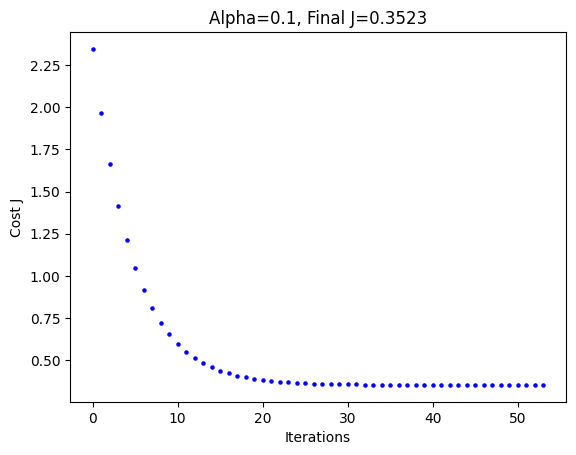

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Навчання моделі
lin_reg = Linear_Regression(alpha=0.1, verbose=0, eps=1e-5)
lin_reg.fit(X_train_scaled, y_train)

print('R2 Score:', lin_reg.score(X_test_scaled, y_test))
lin_reg.draw_cost_changes()

### Multivariable Regression and Comparative Analysis

Ознак у X_tr: 8
Новий R2 Training Score = 0.6035892469476906
Новий R2 Test Score = 0.6094269556521104


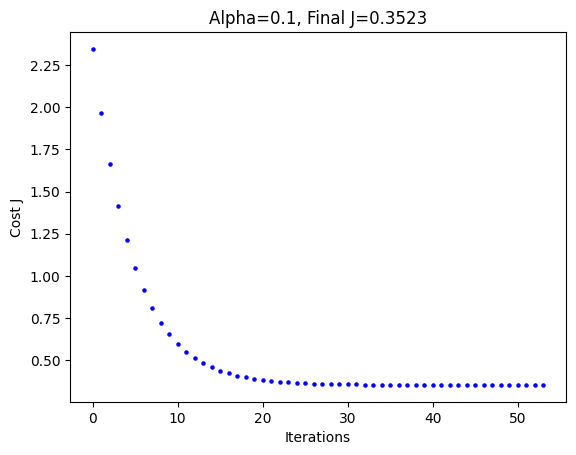

In [13]:
# нові значення
housing = fetch_california_housing()
X_raw = housing.data
y_raw = housing.target

# навчання та тест (75/25)
X_tr, X_te, y_tr, y_te = train_test_split(X_raw, y_raw, test_size=0.25, random_state=2018)

# перевірка: кількість ознак
print(f"Ознак у X_tr: {X_tr.shape[1]}") 

# масштабування 
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

# навчання моделі
lin_reg_multi = Linear_Regression(alpha=0.1, verbose=0, eps=1e-5, max_iter=10000)
lin_reg_multi.fit(X_tr_s, y_tr)

print(f'Новий R2 Training Score = {lin_reg_multi.score(X_tr_s, y_tr)}')
print(f'Новий R2 Test Score = {lin_reg_multi.score(X_te_s, y_te)}')

# графік
lin_reg.draw_cost_changes()

### Comparison of the developed model with the implementation from Sklearn

In [14]:
from sklearn.linear_model import LinearRegression

sk_reg = LinearRegression().fit(X_tr_s, y_tr)
print(f'R2 Sklearn: {sk_reg.score(X_te_s, y_te)}')

R2 Sklearn: 0.6105273580862913


The difference between the results of my model and the library implementation is less than **1%**, which confirms the correctness of the hypothesis function, gradient calculations, and training step implementation.

### ✨ Conclusion

In this work, it is shown that income is an importante factor, but not the only one influencing house prices. Adding more features improves the model accuracy. The data normalization using *StandardScaler* ensures a stable and fast convergence of gradient descent. The developed model gives reasonable results (around 60% accuracy), but for higher precision, more advanced approaches are necessary.